In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imshow, imread
from skimage.color import rgb2gray
import PIL
from PIL import ImageOps,Image
import import_ipynb
from artifacts_removal import artifacts_removal
from bounding_box_numpy import bounding_box_with_resize



importing Jupyter notebook from artifacts_removal.ipynb


FileNotFoundError: No such file: 'f:\Thyroid_analysis\data\preprocessed_images\67.png'

error: OpenCV(4.5.3) c:\users\runneradmin\appdata\local\temp\pip-req-build-uzca7qz1\opencv\modules\imgproc\src\color.simd_helpers.hpp:92: error: (-2:Unspecified error) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<3,4,-1>,struct cv::impl::A0x727538a8::Set<1,-1,-1>,struct cv::impl::A0x727538a8::Set<0,2,5>,2>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 1


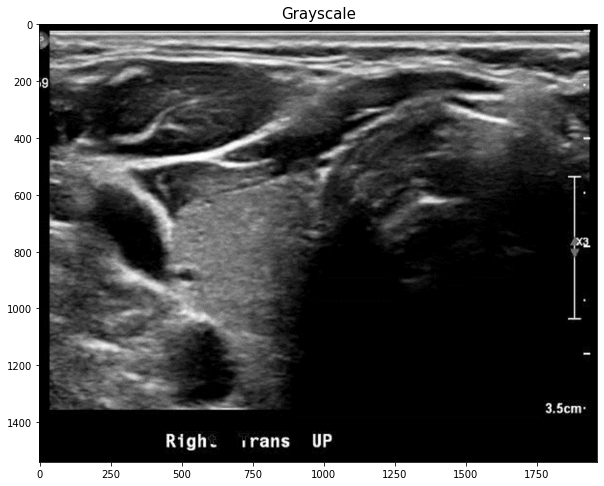

In [4]:

def process_image(raw_image):
    artifacts_removed=artifacts_removal(raw_image)
    cropped_image=bounding_box_with_resize(artifacts_removed)
    return cropped_image


sample=process_image(os.path.join('..', 'data','preprocessed_images', '194.png'))

plt.imshow(sample)
 

In [ ]:
import os
import numpy as np


window_size_x=1900
window_size_y=1300

npz_path = os.path.join('..', 'data', 'X.npz')
folder_path = os.path.join('..', 'data', 'preprocessed_images')




In [ ]:
print(folder_path)
print(npz_path)

In [ ]:
image_filenames = os.listdir(folder_path)
X = np.empty((len(image_filenames), window_size_x, window_size_y), dtype='float64')
for i, image_filename in enumerate(image_filenames):
    if(image_filename=='nodule_findings.csv'):
        continue
    image_path = os.path.join(folder_path, image_filename)
    #print(image_path)
    X[i] = process_image(image_path)
np.savez(npz_path, X)

In [ ]:
from numpy import load
from skimage.io import imshow, imread
import os

data = load(os.path.join('..', 'data', 'X.npz'))
lst = data.files
for item in lst:
    print(item)